# Online Gaming Behavior Analysis/Prediction



This dataset analyzes how demographic characteristics and player profiles influence gaming behavior. By applying exploratory data analysis, visualization techniques, and behavioral pattern discovery, the project seeks to uncover meaningful insights about player engagement and interaction patterns. These findings can support data-driven decision-making in areas such as player retention, game design optimization, and behavioral prediction through machine learning models.

In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import time


In [2]:
df = pd.read_csv(r"C:\Users\rodri\OneDrive\Documentos\PANCHO\PORTFOLIO\ONLINE_GAMING_BEHAVIOR\online_gaming_behavior_insights.csv")

df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [4]:
df.describe().round(2)

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.00,40034.00,40034.00,40034.0,40034.00,40034.00,40034.00,40034.00
mean,29016.50,31.99,12.02,0.2,9.47,94.79,49.66,24.53
std,11556.96,10.04,6.91,0.4,5.76,49.01,28.59,14.43
min,9000.00,15.00,0.00,0.0,0.00,10.00,1.00,0.00
25%,19008.25,23.00,6.07,0.0,4.00,52.00,25.00,12.00
50%,29016.50,32.00,12.01,0.0,9.00,95.00,49.00,25.00
75%,39024.75,41.00,17.96,0.0,14.00,137.00,74.00,37.00
max,49033.00,49.00,24.00,1.0,19.00,179.00,99.00,49.00


In [5]:
# Column Normalization

columns = {"PlayerID": "player_id",
           "Age": "age", 
           "Gender": "gender", 
           "Location": "location", 
           "GameGenre": "game_genre", 
           "PlayTimeHours": "play_time_hours",
           "InGamePurchases": "in_game_purchases",
           "GameDifficulty": "game_difficulty",
           "SessionsPerWeek": "sessions_per_week",
           "AvgSessionDurationMinutes": "avg_session_duration_minutes",
           "PlayerLevel": "player_level",
           "AchievementsUnlocked": "achievements_unlocked",
           "EngagementLevel": "engagement_level"
           }

df.columns = df.columns.str.strip()
df = df.rename(columns=columns)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   player_id                     40034 non-null  int64  
 1   age                           40034 non-null  int64  
 2   gender                        40034 non-null  object 
 3   location                      40034 non-null  object 
 4   game_genre                    40034 non-null  object 
 5   play_time_hours               40034 non-null  float64
 6   in_game_purchases             40034 non-null  int64  
 7   game_difficulty               40034 non-null  object 
 8   sessions_per_week             40034 non-null  int64  
 9   avg_session_duration_minutes  40034 non-null  int64  
 10  player_level                  40034 non-null  int64  
 11  achievements_unlocked         40034 non-null  int64  
 12  engagement_level              40034 non-null  object 
dtypes

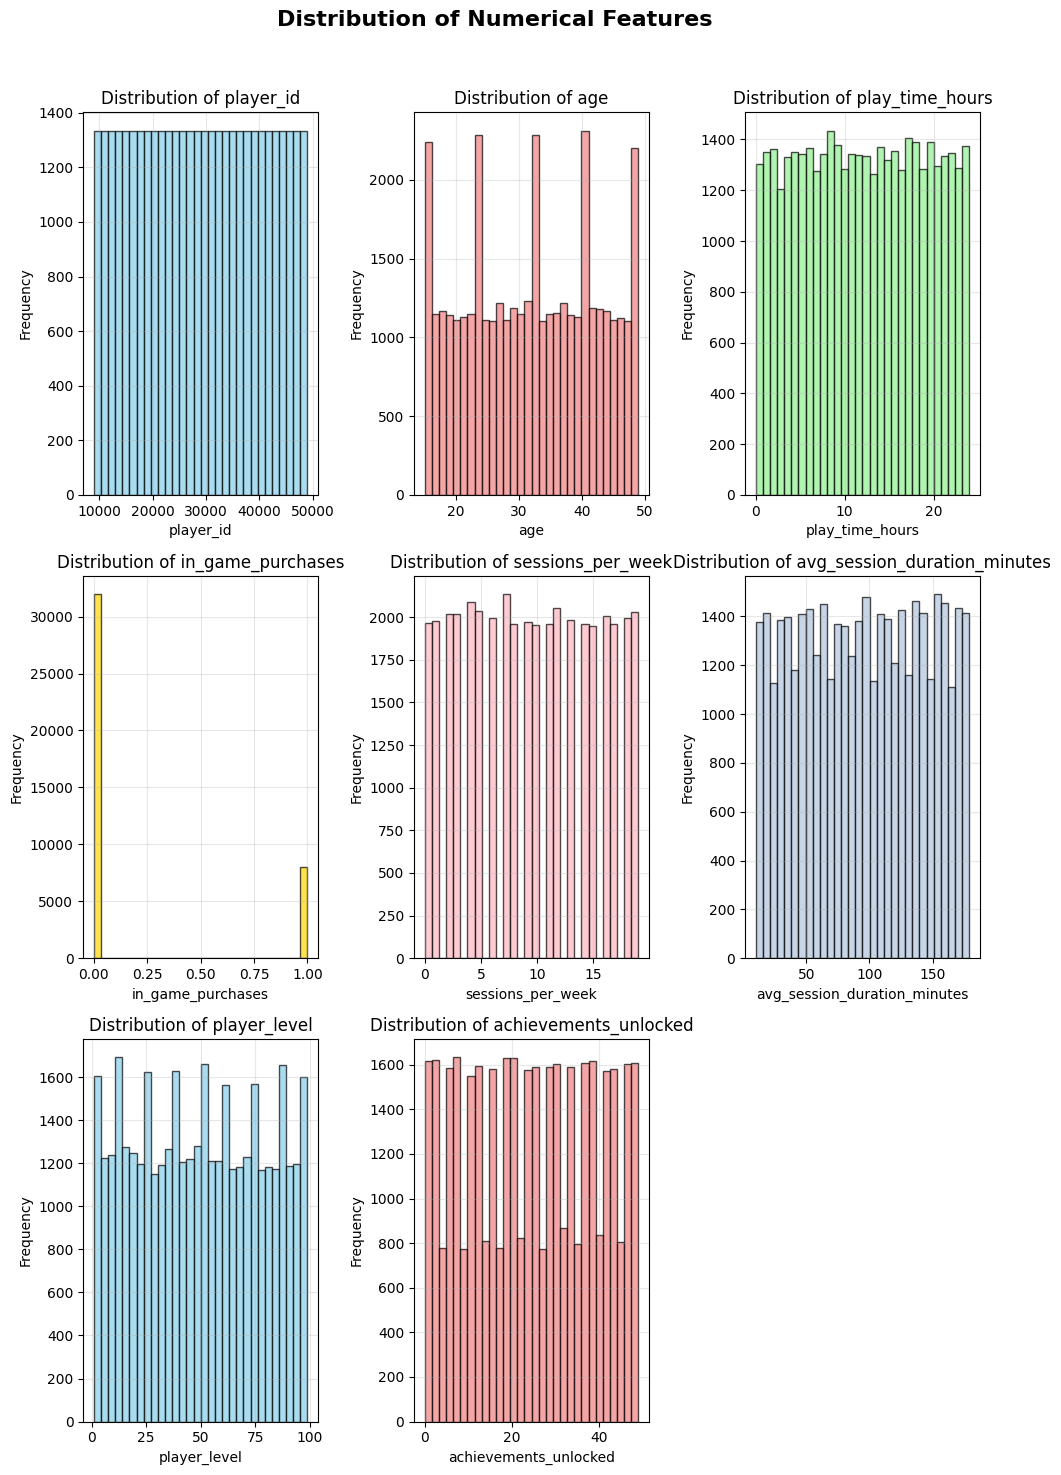

In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in num_cols if c != ['player_id']]

# Define grid size dynamically
n_features = len(num_cols)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

# Flatten axes for easier iteration
axes = axes.flatten()

colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'lightpink', 'lightsteelblue']

# Plot histograms
for i, feature in enumerate(num_cols):
    axes[i].hist(
        df[feature],
        bins=30,
        alpha=0.7,
        color = colors[i % len(colors)],
        edgecolor='black'
    )
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

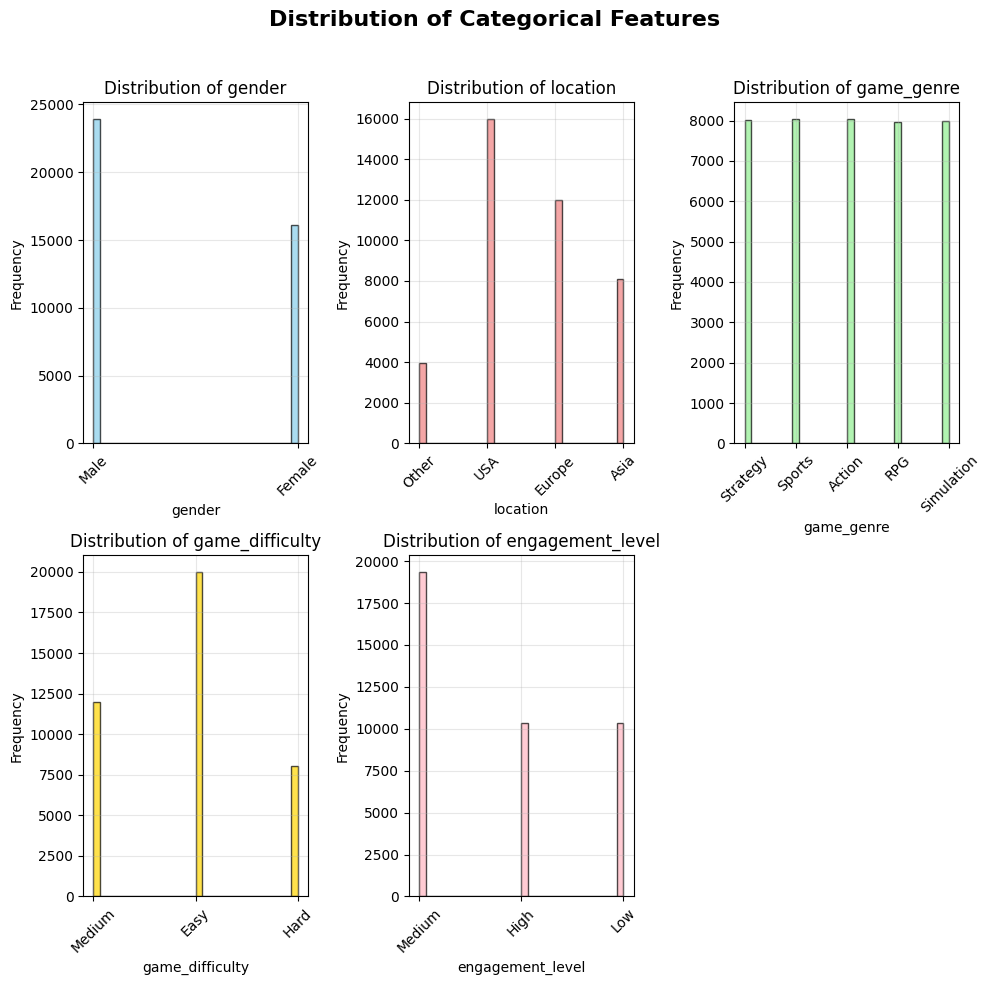

In [7]:
# Define grid size dynamically
c_features = len(cat_cols)
c_cols = 3
c_rows = math.ceil(c_features / c_cols)

# Create subplots
fig, axes = plt.subplots(c_rows, c_cols, figsize=(10, 5 * c_rows))
fig.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold')

# Flatten axes for easier iteration
axes = axes.flatten()

colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'lightpink', 'lightsteelblue']

# Plot histograms
for i, feature in enumerate(cat_cols):
    axes[i].hist(
        df[feature],
        bins=30,
        alpha=0.7,
        color = colors[i % len(colors)],
        edgecolor='black'
    )
    
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [8]:
# Feature Engineering

df['weekly_playtime'] = df['sessions_per_week'] * df['avg_session_duration_minutes']

df['playtime_per_level'] = df['play_time_hours'] / (df['player_level'] + 1)

df['achievements_per_level'] = df['achievements_unlocked'] / (df['player_level'] + 1)

df['sessions_per_hour'] = df['sessions_per_week'] / (df['play_time_hours'] + 1)

df['achievement_progress'] = df['achievements_unlocked'] / (df['play_time_hours'] + 1)

In [9]:
key_features = [
    'age',
    'play_time_hours',
    'player_level',
    'achievements_unlocked',
    'sessions_per_week',
    'avg_session_duration_minutes',
    'weekly_playtime',
    'playtime_per_level',
    'achievements_per_level',
    'sessions_per_hour'
]

X = df.drop(columns=['engagement_level'], axis=1)
y = df['engagement_level']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Dimension de entrenamiento: {X_train.shape}')
print(f'Dimension de prueba: {X_test.shape}')

Dimension de entrenamiento: (32027, 17)
Dimension de prueba: (8007, 17)


In [11]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

engagement_level
Medium    0.483811
High      0.259188
Low       0.257002
Name: proportion, dtype: float64
engagement_level
Medium    0.484451
Low       0.261396
High      0.254153
Name: proportion, dtype: float64


In [12]:
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(cat_features)
print(num_features)


['gender', 'location', 'game_genre', 'game_difficulty']
['player_id', 'age', 'play_time_hours', 'in_game_purchases', 'sessions_per_week', 'avg_session_duration_minutes', 'player_level', 'achievements_unlocked', 'weekly_playtime', 'playtime_per_level', 'achievements_per_level', 'sessions_per_hour', 'achievement_progress']


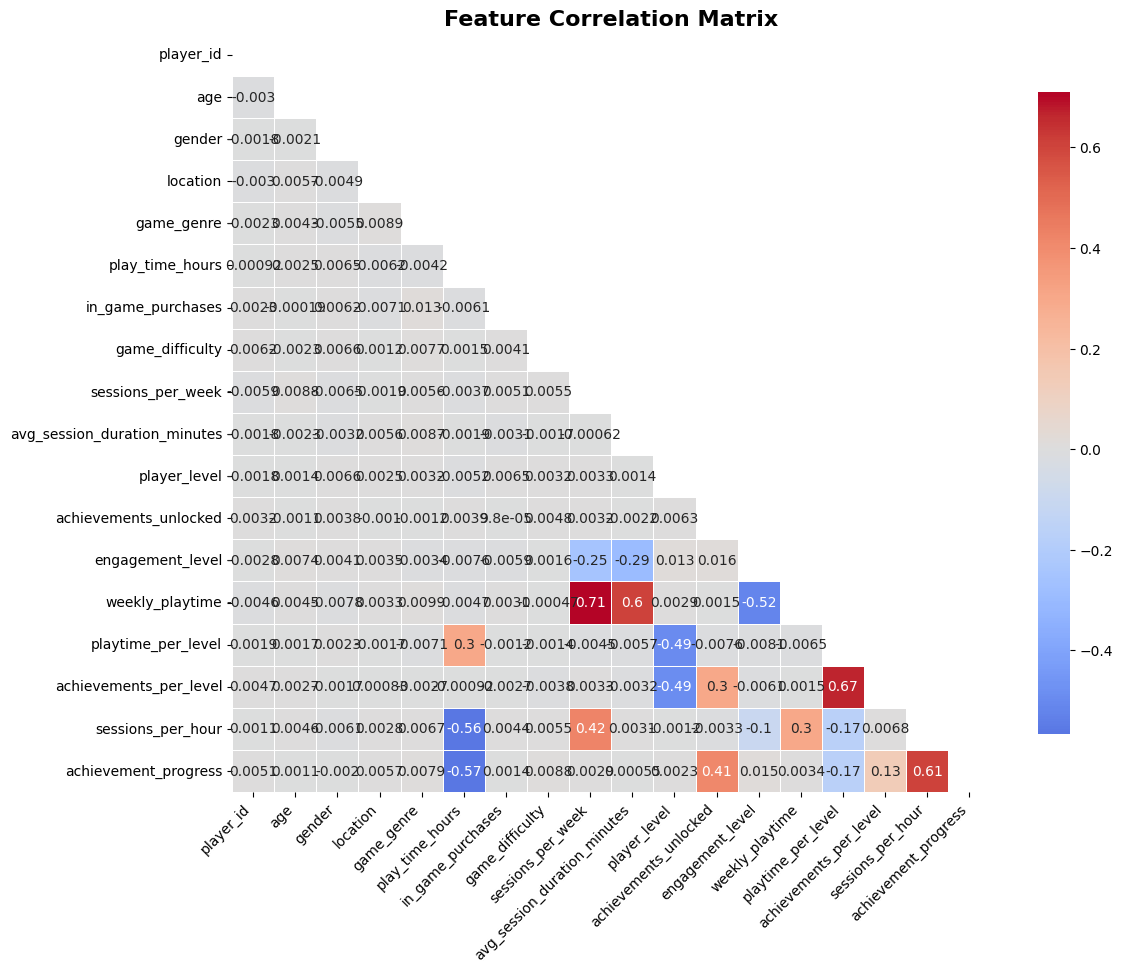

In [13]:
# Prepare data for correlation matrix
correlation_df = df.copy()

# Encode categorical variables for correlation analysis
le = LabelEncoder()
categorical_for_corr = ['gender', 'location', 'game_genre', 'game_difficulty', 'engagement_level']
for col in categorical_for_corr:
    correlation_df[col] = le.fit_transform(correlation_df[col])

plt.figure(figsize=(12, 10))
correlation_matrix = correlation_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
from scipy.sparse import hstack

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[num_features])
X_test_scaled = scaler.transform(X_test[num_features])

# One-Hot Encoding for Categorical Features
ohe = OneHotEncoder(handle_unknown='ignore')
X_train_encoded = ohe.fit_transform(X_train[cat_features])
X_test_encoded = ohe.transform(X_test[cat_features])

X_train_prep = hstack([X_train_scaled, X_train_encoded])
X_test_prep = hstack([X_test_scaled, X_test_encoded])

print(f'X_train_prep shape: {X_train_prep.shape}')
print(f'X_test_prep shape: {X_test_prep.shape}')

X_train_prep shape: (32027, 27)
X_test_prep shape: (8007, 27)


In [15]:
def evaluar_clasificador(nombre, modelo, X_train, y_train, X_test, y_test):

    t0 = time.time()
    modelo.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"=== {nombre} ===")
    print(f"Tiempo train: {train_time:.2f}s | Accuracy: {acc:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | Precision: {prec:.4f}")

    if hasattr(modelo, "predict_proba"):
        try:
            y_prob = modelo.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
            print(f"AUC: {auc:.4f}")
        except:
            auc = None
            print("AUC: No disponible")
    else:
        auc = None
        print("AUC: No disponible")

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print()

    return {
        "modelo": nombre,
        "train_time": train_time,
        "accuracy": acc,
        "recall": rec,
        "f1": f1,
        "precision": prec,
        "auc_roc": auc
    }

In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_prep, y_train)

y_dummy_pred = dummy.predict(X_test_prep)

print("Accuracy:", accuracy_score(y_test, y_dummy_pred))
print("Recall:", recall_score(y_test, y_dummy_pred, average='weighted'))
print("F1:", f1_score(y_test, y_dummy_pred, average='weighted'))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_dummy_pred))



Accuracy: 0.4844511052828775
Recall: 0.4844511052828775
F1: 0.31620155433152985
Matriz de confusión:
 [[   0    0 2035]
 [   0    0 2093]
 [   0    0 3879]]


In [17]:
results = []

best_model = None
best_score = 0
best_name = None

for C in [0.1, 0.5, 1, 2, 5]:

    lr = LogisticRegression(
        C=C,
        max_iter=2000,
        solver='lbfgs',
        class_weight='balanced',
        random_state=42
    )

    nombre = f"LogReg C={C}"

    res = evaluar_clasificador(
        nombre,
        lr,
        X_train_prep,
        y_train,
        X_test_prep,
        y_test
    )

    results.append(res)

    if res["auc_roc"] is not None and res["auc_roc"] > best_score:
        best_score = res["auc_roc"]
        best_model = lr
        best_name = nombre

=== LogReg C=0.1 ===
Tiempo train: 0.23s | Accuracy: 0.8294 | Recall: 0.8294 | F1: 0.8306 | Precision: 0.8419
AUC: 0.9324
Matriz de confusión:
 [[1815   87  133]
 [  73 1841  179]
 [ 234  660 2985]]

=== LogReg C=0.5 ===
Tiempo train: 0.23s | Accuracy: 0.8296 | Recall: 0.8296 | F1: 0.8308 | Precision: 0.8424
AUC: 0.9326
Matriz de confusión:
 [[1813   87  135]
 [  72 1847  174]
 [ 235  661 2983]]

=== LogReg C=1 ===
Tiempo train: 0.24s | Accuracy: 0.8301 | Recall: 0.8301 | F1: 0.8313 | Precision: 0.8427
AUC: 0.9327
Matriz de confusión:
 [[1811   87  137]
 [  72 1849  172]
 [ 235  657 2987]]

=== LogReg C=2 ===
Tiempo train: 0.21s | Accuracy: 0.8300 | Recall: 0.8300 | F1: 0.8312 | Precision: 0.8427
AUC: 0.9327
Matriz de confusión:
 [[1810   88  137]
 [  72 1849  172]
 [ 235  657 2987]]

=== LogReg C=5 ===
Tiempo train: 0.19s | Accuracy: 0.8303 | Recall: 0.8303 | F1: 0.8314 | Precision: 0.8429
AUC: 0.9327
Matriz de confusión:
 [[1810   88  137]
 [  72 1850  171]
 [ 234  657 2988]]



In [18]:
best_model = None
best_score = 0
best_name = None

param_grid_tree = [
    {'max_depth': 3},
    {'max_depth': 5},
    {'max_depth': 7},
    {'max_depth': 10},
    {'max_depth': None},
]

for params in param_grid_tree:
    tree = DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,
        **params
    )
    
    nombre = f"Tree depth={params['max_depth']}"
    res = evaluar_clasificador(nombre, tree, X_train_prep, y_train, X_test_prep, y_test)
    results.append(res)

    if res["auc_roc"] is not None and res["auc_roc"] > best_score:
        best_score = res["auc_roc"]
        best_model = tree
        best_name = nombre

=== Tree depth=3 ===
Tiempo train: 0.15s | Accuracy: 0.8834 | Recall: 0.8834 | F1: 0.8839 | Precision: 0.8861
AUC: 0.9318
Matriz de confusión:
 [[1784   72  179]
 [  63 1877  153]
 [ 106  361 3412]]

=== Tree depth=5 ===
Tiempo train: 0.26s | Accuracy: 0.9041 | Recall: 0.9041 | F1: 0.9043 | Precision: 0.9048
AUC: 0.9388
Matriz de confusión:
 [[1809   73  153]
 [  63 1884  146]
 [ 101  232 3546]]

=== Tree depth=7 ===
Tiempo train: 0.43s | Accuracy: 0.9156 | Recall: 0.9156 | F1: 0.9155 | Precision: 0.9155
AUC: 0.9390
Matriz de confusión:
 [[1815   71  149]
 [  62 1881  150]
 [ 108  136 3635]]

=== Tree depth=10 ===
Tiempo train: 0.66s | Accuracy: 0.9100 | Recall: 0.9100 | F1: 0.9098 | Precision: 0.9098
AUC: 0.9235
Matriz de confusión:
 [[1806   79  150]
 [  74 1854  165]
 [ 123  130 3626]]

=== Tree depth=None ===
Tiempo train: 2.48s | Accuracy: 0.8424 | Recall: 0.8424 | F1: 0.8426 | Precision: 0.8428
AUC: 0.8760
Matriz de confusión:
 [[1669  156  210]
 [ 147 1698  248]
 [ 234  267 3378

In [19]:
best_model = None
best_score = 0
best_name = None

param_grid_rf = [
    {'n_estimators': 100, 'max_depth': 5},
    {'n_estimators': 200, 'max_depth': 5},
    {'n_estimators': 200, 'max_depth': 10},
    {'n_estimators': 300, 'max_depth': 10},
    {'n_estimators': 300, 'max_depth': None},
]

for params in param_grid_rf:
    rf = RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        **params
    )
    
    nombre = f"RF n={params['n_estimators']} depth={params['max_depth']}"
    res = evaluar_clasificador(nombre, rf, X_train_prep, y_train, X_test_prep, y_test)
    results.append(res)

    if res["auc_roc"] is not None and res["auc_roc"] > best_score:
        best_score = res["auc_roc"]
        best_model = rf
        best_name = nombre

=== RF n=100 depth=5 ===
Tiempo train: 0.52s | Accuracy: 0.8951 | Recall: 0.8951 | F1: 0.8953 | Precision: 0.8962
AUC: 0.9383
Matriz de confusión:
 [[1796   72  167]
 [  65 1880  148]
 [ 117  271 3491]]

=== RF n=200 depth=5 ===
Tiempo train: 0.98s | Accuracy: 0.8943 | Recall: 0.8943 | F1: 0.8946 | Precision: 0.8956
AUC: 0.9388
Matriz de confusión:
 [[1795   72  168]
 [  65 1881  147]
 [ 116  278 3485]]

=== RF n=200 depth=10 ===
Tiempo train: 3.47s | Accuracy: 0.9140 | Recall: 0.9140 | F1: 0.9139 | Precision: 0.9141
AUC: 0.9423
Matriz de confusión:
 [[1810   69  156]
 [  62 1889  142]
 [  93  167 3619]]

=== RF n=300 depth=10 ===
Tiempo train: 5.29s | Accuracy: 0.9135 | Recall: 0.9135 | F1: 0.9134 | Precision: 0.9136
AUC: 0.9421
Matriz de confusión:
 [[1809   69  157]
 [  62 1886  145]
 [  92  168 3619]]

=== RF n=300 depth=None ===
Tiempo train: 13.38s | Accuracy: 0.9208 | Recall: 0.9208 | F1: 0.9206 | Precision: 0.9208
AUC: 0.9434
Matriz de confusión:
 [[1819   68  148]
 [  62 1876 

In [20]:
best_model = None
best_score = 0
best_name = None

param_grid_cb = [
    {'depth': 4, 'learning_rate': 0.05},
    {'depth': 6, 'learning_rate': 0.05},
    {'depth': 8, 'learning_rate': 0.05},
    {'depth': 6, 'learning_rate': 0.1},
    {'depth': 8, 'learning_rate': 0.1},
]

for params in param_grid_cb:
    cb = CatBoostClassifier(
        iterations=300,
        eval_metric='AUC',
        verbose=0,
        random_seed=42,
        **params
    )
    
    nombre = f"CatBoost depth={params['depth']} lr={params['learning_rate']}"
    res = evaluar_clasificador(nombre, cb, X_train_prep, y_train, X_test_prep, y_test)
    results.append(res)

    if res["auc_roc"] is not None and res["auc_roc"] > best_score:
        best_score = res["auc_roc"]
        best_model = cb
        best_name = nombre

=== CatBoost depth=4 lr=0.05 ===
Tiempo train: 1.64s | Accuracy: 0.9224 | Recall: 0.9224 | F1: 0.9222 | Precision: 0.9224
AUC: 0.9436
Matriz de confusión:
 [[1811   69  155]
 [  61 1888  144]
 [  82  110 3687]]

=== CatBoost depth=6 lr=0.05 ===
Tiempo train: 2.05s | Accuracy: 0.9232 | Recall: 0.9232 | F1: 0.9230 | Precision: 0.9232
AUC: 0.9441
Matriz de confusión:
 [[1813   69  153]
 [  61 1890  142]
 [  84  106 3689]]

=== CatBoost depth=8 lr=0.05 ===
Tiempo train: 4.76s | Accuracy: 0.9238 | Recall: 0.9238 | F1: 0.9236 | Precision: 0.9238
AUC: 0.9440
Matriz de confusión:
 [[1817   68  150]
 [  62 1886  145]
 [  84  101 3694]]

=== CatBoost depth=6 lr=0.1 ===
Tiempo train: 1.93s | Accuracy: 0.9223 | Recall: 0.9223 | F1: 0.9221 | Precision: 0.9223
AUC: 0.9436
Matriz de confusión:
 [[1814   68  153]
 [  60 1883  150]
 [  86  105 3688]]

=== CatBoost depth=8 lr=0.1 ===
Tiempo train: 5.44s | Accuracy: 0.9221 | Recall: 0.9221 | F1: 0.9218 | Precision: 0.9220
AUC: 0.9438
Matriz de confusión:

In [21]:

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

best_model = None
best_score = 0
best_name = None

param_grid_xgb = [
    {'max_depth': 3, 'learning_rate': 0.05},
    {'max_depth': 4, 'learning_rate': 0.05},
    {'max_depth': 5, 'learning_rate': 0.05},
    {'max_depth': 4, 'learning_rate': 0.1},
    {'max_depth': 5, 'learning_rate': 0.1},
]

for params in param_grid_xgb:
    xgb = XGBClassifier(
        n_estimators=300,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        **params
    )

    nombre = f"XGB depth={params['max_depth']} lr={params['learning_rate']}"
    res = evaluar_clasificador(nombre, xgb, X_train_prep, y_train_enc, X_test_prep, y_test_enc)
    results.append(res)

    if res["auc_roc"] is not None and res["auc_roc"] > best_score:
        best_score = res["auc_roc"]
        best_model = xgb
        best_name = nombre

=== XGB depth=3 lr=0.05 ===
Tiempo train: 1.11s | Accuracy: 0.9223 | Recall: 0.9223 | F1: 0.9221 | Precision: 0.9223
AUC: 0.9427
Matriz de confusión:
 [[1808   69  158]
 [  61 1886  146]
 [  81  107 3691]]

=== XGB depth=4 lr=0.05 ===
Tiempo train: 1.23s | Accuracy: 0.9231 | Recall: 0.9231 | F1: 0.9229 | Precision: 0.9230
AUC: 0.9433
Matriz de confusión:
 [[1816   69  150]
 [  62 1888  143]
 [  87  105 3687]]

=== XGB depth=5 lr=0.05 ===
Tiempo train: 1.48s | Accuracy: 0.9232 | Recall: 0.9232 | F1: 0.9230 | Precision: 0.9231
AUC: 0.9449
Matriz de confusión:
 [[1818   68  149]
 [  61 1883  149]
 [  89   99 3691]]

=== XGB depth=4 lr=0.1 ===
Tiempo train: 1.33s | Accuracy: 0.9232 | Recall: 0.9232 | F1: 0.9230 | Precision: 0.9231
AUC: 0.9442
Matriz de confusión:
 [[1815   69  151]
 [  61 1887  145]
 [  86  103 3690]]

=== XGB depth=5 lr=0.1 ===
Tiempo train: 1.50s | Accuracy: 0.9232 | Recall: 0.9232 | F1: 0.9230 | Precision: 0.9232
AUC: 0.9429
Matriz de confusión:
 [[1815   68  152]
 [  6

In [22]:
res_df = pd.DataFrame(results).sort_values("auc_roc", ascending=False)
res_df.head(10)

,modelo,train_time,accuracy,recall,f1,precision,auc_roc
22,XGB depth=5 lr=0.05,1.484584,0.923192,0.923192,0.922989,0.923143,0.944908
23,XGB depth=4 lr=0.1,1.333097,0.923192,0.923192,0.922992,0.923147,0.944209
16,CatBoost depth=6 lr=0.05,2.048320,0.923192,0.923192,0.922996,0.923155,0.944112
17,CatBoost depth=8 lr=0.05,4.758525,0.923817,0.923817,0.923611,0.923774,0.944025
19,CatBoost depth=8 lr=0.1,5.441784,0.922068,0.922068,0.921844,0.922037,0.943775
18,CatBoost depth=6 lr=0.1,1.933958,0.922318,0.922318,0.922113,0.922293,0.943642
15,CatBoost depth=4 lr=0.05,1.637383,0.922443,0.922443,0.922245,0.922424,0.943556
14,RF n=300 depth=None,13.378249,0.920819,0.920819,0.920636,0.920769,0.943388
21,XGB depth=4 lr=0.05,1.230362,0.923067,0.923067,0.922878,0.923006,0.943347
24,XGB depth=5 lr=0.1,1.502501,0.923192,0.923192,0.922980,0.923160,0.942938


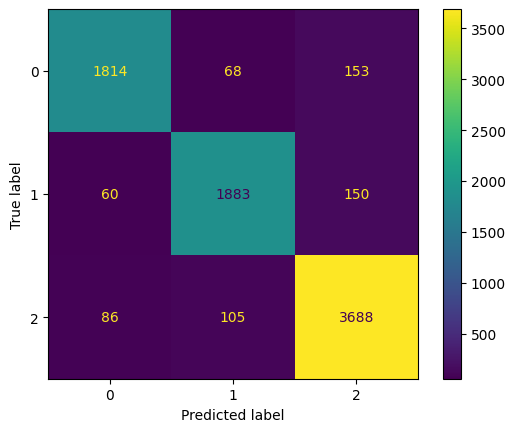

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = CatBoostClassifier(
    depth=6,
    learning_rate=0.1,
    iterations=300,
    random_state=42,
    verbose=0
)

best_model.fit(X_train_prep, y_train_enc)

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_prep,
    y_test_enc
)

In [24]:
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

ValueError: All arrays must be of the same length

C:\Users\rodri\AppData\Local\Temp\ipykernel_32036\1029829232.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


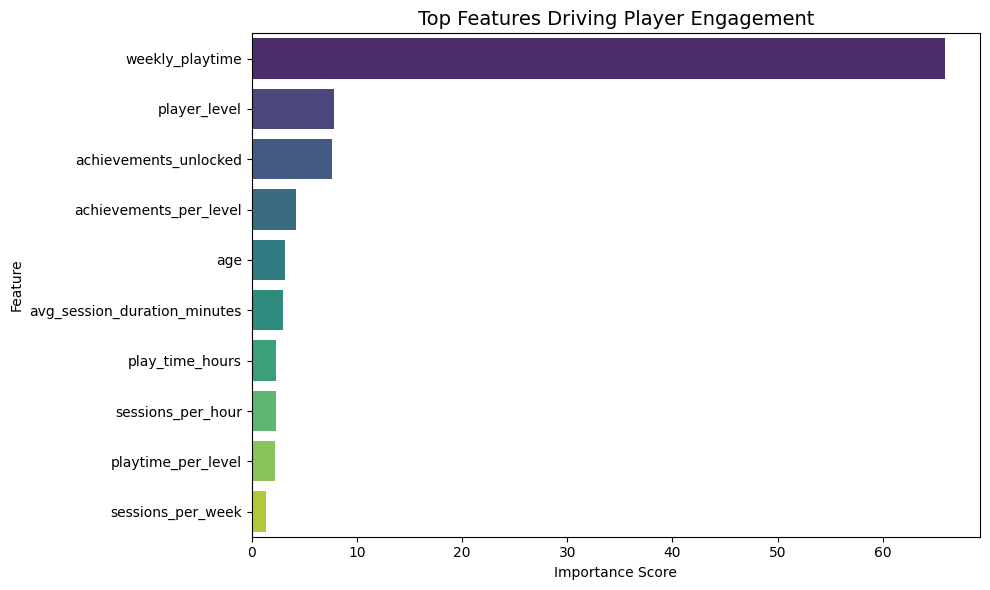

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='importance',
    y='feature',
    palette='viridis'
)

plt.title('Top Features Driving Player Engagement', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()